### Plot snapshots of surface vorticity, numerical mixing, and physical mixing
Horizontal resolutions used: 100 m, 500 m, 1km, 2km, 5km, and 10km

In [1]:
#Packages 
import numpy as np
import xarray as xr
import glob
import cmocean.cm as cmo
import matplotlib.cm as cmx
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
import warnings
warnings.filterwarnings("ignore") #turns off annoying warnings
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import FuncFormatter
import mosaic
from matplotlib.colors import SymLogNorm
from matplotlib.colors import LinearSegmentedColormap
import os
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable

### Interpolate physical mixing and center vertices for plotting 

In [2]:
def interp_mphy(ds):
    # Interpolate only the top 2 levels of chiPhyVerSalt. This greatly 
    # speeds up processing time for the 100 m case and avoids OOM errors
    mphys_interp_top2 = 0.5 * (
        ds.timeCustom_avg_chiPhyVerTracer_chiPhyVerSalt.isel(nVertLevelsP1=slice(0, 2)) +  # levels 0–1
        ds.timeCustom_avg_chiPhyVerTracer_chiPhyVerSalt.isel(nVertLevelsP1=slice(1, 3))    # levels 1–2
    )
    mphys_interp_top2 = mphys_interp_top2.rename({'nVertLevelsP1': 'nVertLevels'})
    
    # Assign only top 2 nVertLevels coordinates
    mphys_interp_top2 = mphys_interp_top2.assign_coords(
        nVertLevels=ds.nVertLevels.isel(nVertLevels=slice(0, 2))
    )

    # Create a copy of the original variable (with all levels)
    full_salt = ds.timeCustom_avg_chiPhyVerTracer_chiPhyVerSalt
    # Drop the top nVertLevelsP1 level to get nVertLevels (standard practice)
    full_salt_interp = full_salt.isel(nVertLevelsP1=slice(1, None))
    full_salt_interp = full_salt_interp.rename({'nVertLevelsP1': 'nVertLevels'})
    full_salt_interp = full_salt_interp.assign_coords(nVertLevels=ds.nVertLevels)

    # Replace top 2 levels with interpolated values
    full_salt_interp = full_salt_interp.copy()
    full_salt_interp[{ 'nVertLevels': slice(0, 2) }] = mphys_interp_top2

    # Update dataset
    ds['chiPhyVerSalt'] = full_salt_interp

    return ds

def center_vertices(dsg, hres):
    # Clean up the indexing so the domain is centered for plotting

    # Original vertices (x,y) arrays
    xv = dsg.xVertex.values
    yv = dsg.yVertex.values
    
    # Compute the new vertices based on your filtering and offset logic:
    
    # 1. Extract verticesOnCell (assuming shape: [nCells, maxVerticesPerCell])
    voc = dsg.verticesOnCell.values
    
    # 2. Build verts as in your snippet (shape: [nCells, maxVerticesPerCell, 2])
    verts = np.dstack((xv[voc - 1], yv[voc - 1]))
    nverts = np.sum(voc != 0, axis=1)
    verts_list = [vert[:n] for vert, n in zip(verts, nverts)]
    
    # 3. Filter verts using np.ptp
    idx = [np.ptp(vert[:, 0]) < 50000 for vert in verts_list]
    verts_filtered = np.array(verts_list)[idx]
    
    # 4. Copy and apply offsets
    nuverts = verts_filtered.copy()
    m_dsx = hres
    nuverts[:, :, 0] += m_dsx / 2
    nuverts[:, :, 1] -= m_dsx
    
    # Now, update dsg's xVertex and yVertex arrays accordingly:
    # But note: verts are grouped by cell, so we need to flatten and assign properly.
    
    # Because verts_filtered is a filtered subset of verts_list,
    # you should update only those cells where idx is True.
    
    # Get indices of cells that passed filter
    filtered_cells = np.where(idx)[0]
    
    # Create copies of xVertex and yVertex to modify
    new_xVertex = xv.copy()
    new_yVertex = yv.copy()
    
    # Loop over filtered cells and update the corresponding vertex coords
    for cell_i, verts_cell in zip(filtered_cells, nuverts):
        nv = verts_cell.shape[0]  # number of vertices for this cell
        vertex_inds = voc[cell_i, :nv] - 1  # zero-based vertex indices for this cell
        new_xVertex[vertex_inds] = verts_cell[:, 0]
        new_yVertex[vertex_inds] = verts_cell[:, 1]
    
    # Assign back to dsg (if dsg is an xarray Dataset or DataArray)
    dsg['xVertex'].values = new_xVertex
    dsg['yVertex'].values = new_yVertex

### Open output and apply functions, but only at a single timestep to reduce computational time for the 100 m simulation

In [18]:
pathsg = ['/pscratch/sd/d/dylan617/bichan/mpaso/new_hres/10km/channel_10000m_50_layers_init.nc',
         '/pscratch/sd/d/dylan617/bichan/mpaso/new_hres/5km/channel_5000m_50_layers_init.nc',
         '/pscratch/sd/d/dylan617/bichan/mpaso/new_hres/2km/channel_2000m_50_layers_init.nc',
         '/pscratch/sd/d/dylan617/bichan/mpaso/new_hres/1km/channel_1000m_50_layers_init.nc',
         '/pscratch/sd/d/dylan617/bichan/mpaso/new_hres/500m/channel_500m_50_layers_init.nc',
         '/pscratch/sd/d/dylan617/bichan/mpaso/new_hres/200m/channel_200m_50_layers_init.nc',
         '/pscratch/sd/d/dylan617/bichan/mpaso/new_hres/100m/channel_100m_50_layers_init.nc'
         ]
pathsd = [
    "/pscratch/sd/d/dylan617/bichan/mpaso/new_hres/10km/analysis_members/mpaso.hist.am.timeSeriesStatsCustom_10000m_50_layers_gmd.0001-01-01.nc",
    "/pscratch/sd/d/dylan617/bichan/mpaso/new_hres/5km/analysis_members/mpaso.hist.am.timeSeriesStatsCustom_5000m_50_layers_gmd.0001-01-01.nc",
    "/pscratch/sd/d/dylan617/bichan/mpaso/new_hres/2km/analysis_members/mpaso.hist.am.timeSeriesStatsCustom_2000m_50_layers_gmd.0001-01-01.nc",
    "/pscratch/sd/d/dylan617/bichan/mpaso/new_hres/1km/analysis_members/mpaso.hist.am.timeSeriesStatsCustom_1000m_50_layers_gmd.0001-01-01.nc",
    "/pscratch/sd/d/dylan617/bichan/mpaso/new_hres/500m/analysis_members/mpaso.hist.am.timeSeriesStatsCustom_500m_50_layers_gmd.0001-01-01.nc",
    "/pscratch/sd/d/dylan617/bichan/mpaso/new_hres/200m/analysis_members/mpaso.hist.am.timeSeriesStatsCustom_500m_50_layers_gmd.0001-01-01.nc",
    "/pscratch/sd/k/kehinson/seahorce/mpaso_channel/bichan_v202601/100m/analysis_members/mpaso.hist.am.timeSeriesStatsCustom_100m_50_layers_gmd_day_0_29.nc"
]

snapshot_time = b"0001-01-12_00:00:00"  # Time to select
datasets = {}

for init_path, data_glob in zip(pathsg, pathsd):

    if not os.path.exists(init_path):
        print(f"Missing init file: {init_path}")
        continue

    data_files = sorted(glob.glob(data_glob))
    if len(data_files) == 0:
        print(f"No analysis files found for pattern: {data_glob}")
        continue

    # Infer resolution key from filename
    # e.g. channel_1000m_50_layers_init.nc → 1000m
    fname = os.path.basename(init_path)
    res_token = fname.split("_")[1]   # '1000m'
    res_key = res_token

    datasets[res_key] = {}

    # Open init (geometry) file
    dsg = xr.open_mfdataset(init_path)

    for data_file in data_files:
        dso = xr.open_mfdataset(data_file)

        # Use xtime as Time
        if "xtime" in dso:
            dso["Time"] = dso.xtime
        else:
            print(f"No xtime in {data_file}")
            continue

        if snapshot_time not in dso.Time.values:
            print(f"Time {snapshot_time} not found in {data_file}")
            continue

        dso = dso.sel(Time=snapshot_time)

        # Use layer count as key (always z50 here)
        layer_key = "z50"

        datasets[res_key][layer_key] = {
            "output": dso,
            "init": dsg
        }

print("Finished loading datasets.")



Finished loading datasets.


In [19]:
for res_key, layers_dict in datasets.items():

    # Extract dx in meters from res_key (e.g. "1000m" -> 1000)
    dx = int(res_key.replace("m", ""))
    print(f"{res_key}: dx = {dx}")

    for layer_key, files in layers_dict.items():

        # --- GRID (init file) ---
        init_ds = files.get("init")
        if init_ds is not None:
            center_vertices(init_ds, dx)

        # --- DVD / timeSeriesStatsCustom ---
        output_ds = files.get("output")
        if output_ds is not None:
            interp_mphy(output_ds)


10000m: dx = 10000
5000m: dx = 5000
2000m: dx = 2000
1000m: dx = 1000
500m: dx = 500
200m: dx = 200
100m: dx = 100


### Pre-plotting for mosaic and colorbar tweaks

In [6]:
# Create a descriptor dictionary dynamically
descriptors = {}

for res_key, layers_dict in datasets.items():
    # Grab one of the 'init' datasets to build the descriptor
    # We'll use the first available layer
    if not layers_dict:
        continue

    first_layer = next(iter(layers_dict.values()))
    init_ds = first_layer['init']
    
    # Create and store descriptor
    descriptors[res_key] = mosaic.Descriptor(init_ds, use_latlon=False)


# Used for plotting mnum on a diverging log colorbar
# Otherwise the extrema look the same for most cmocean maps. That is, 
# you can't tell dark reds or blues apart. 
def truncate_colormap(cmap, minval=0.0, maxval=0.8, n=256):
    """Truncates a colormap to use only part of the range."""
    new_cmap = LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

curl = truncate_colormap(plt.get_cmap('cmo.curl'), 0.15, 0.85)

# Helper to safely compute log10 for plotting, otherwise it is masked for 
# very small values
def safe_log10(data, floor=1e-50):
    """Compute log10 of xarray DataArray safely, keeping dimensions and attrs."""
    # Replace nonpositive or nonfinite values with floor
    data_clean = data.where((data > 0) & np.isfinite(data), other=floor)
    return np.log10(data_clean)

### Plot vorticity, numerical mixing, and physical mixing

In [7]:
print("datasets keys:", list(datasets.keys()))


datasets keys: ['10000m', '5000m', '2000m', '1000m', '500m', '200m', '100m']


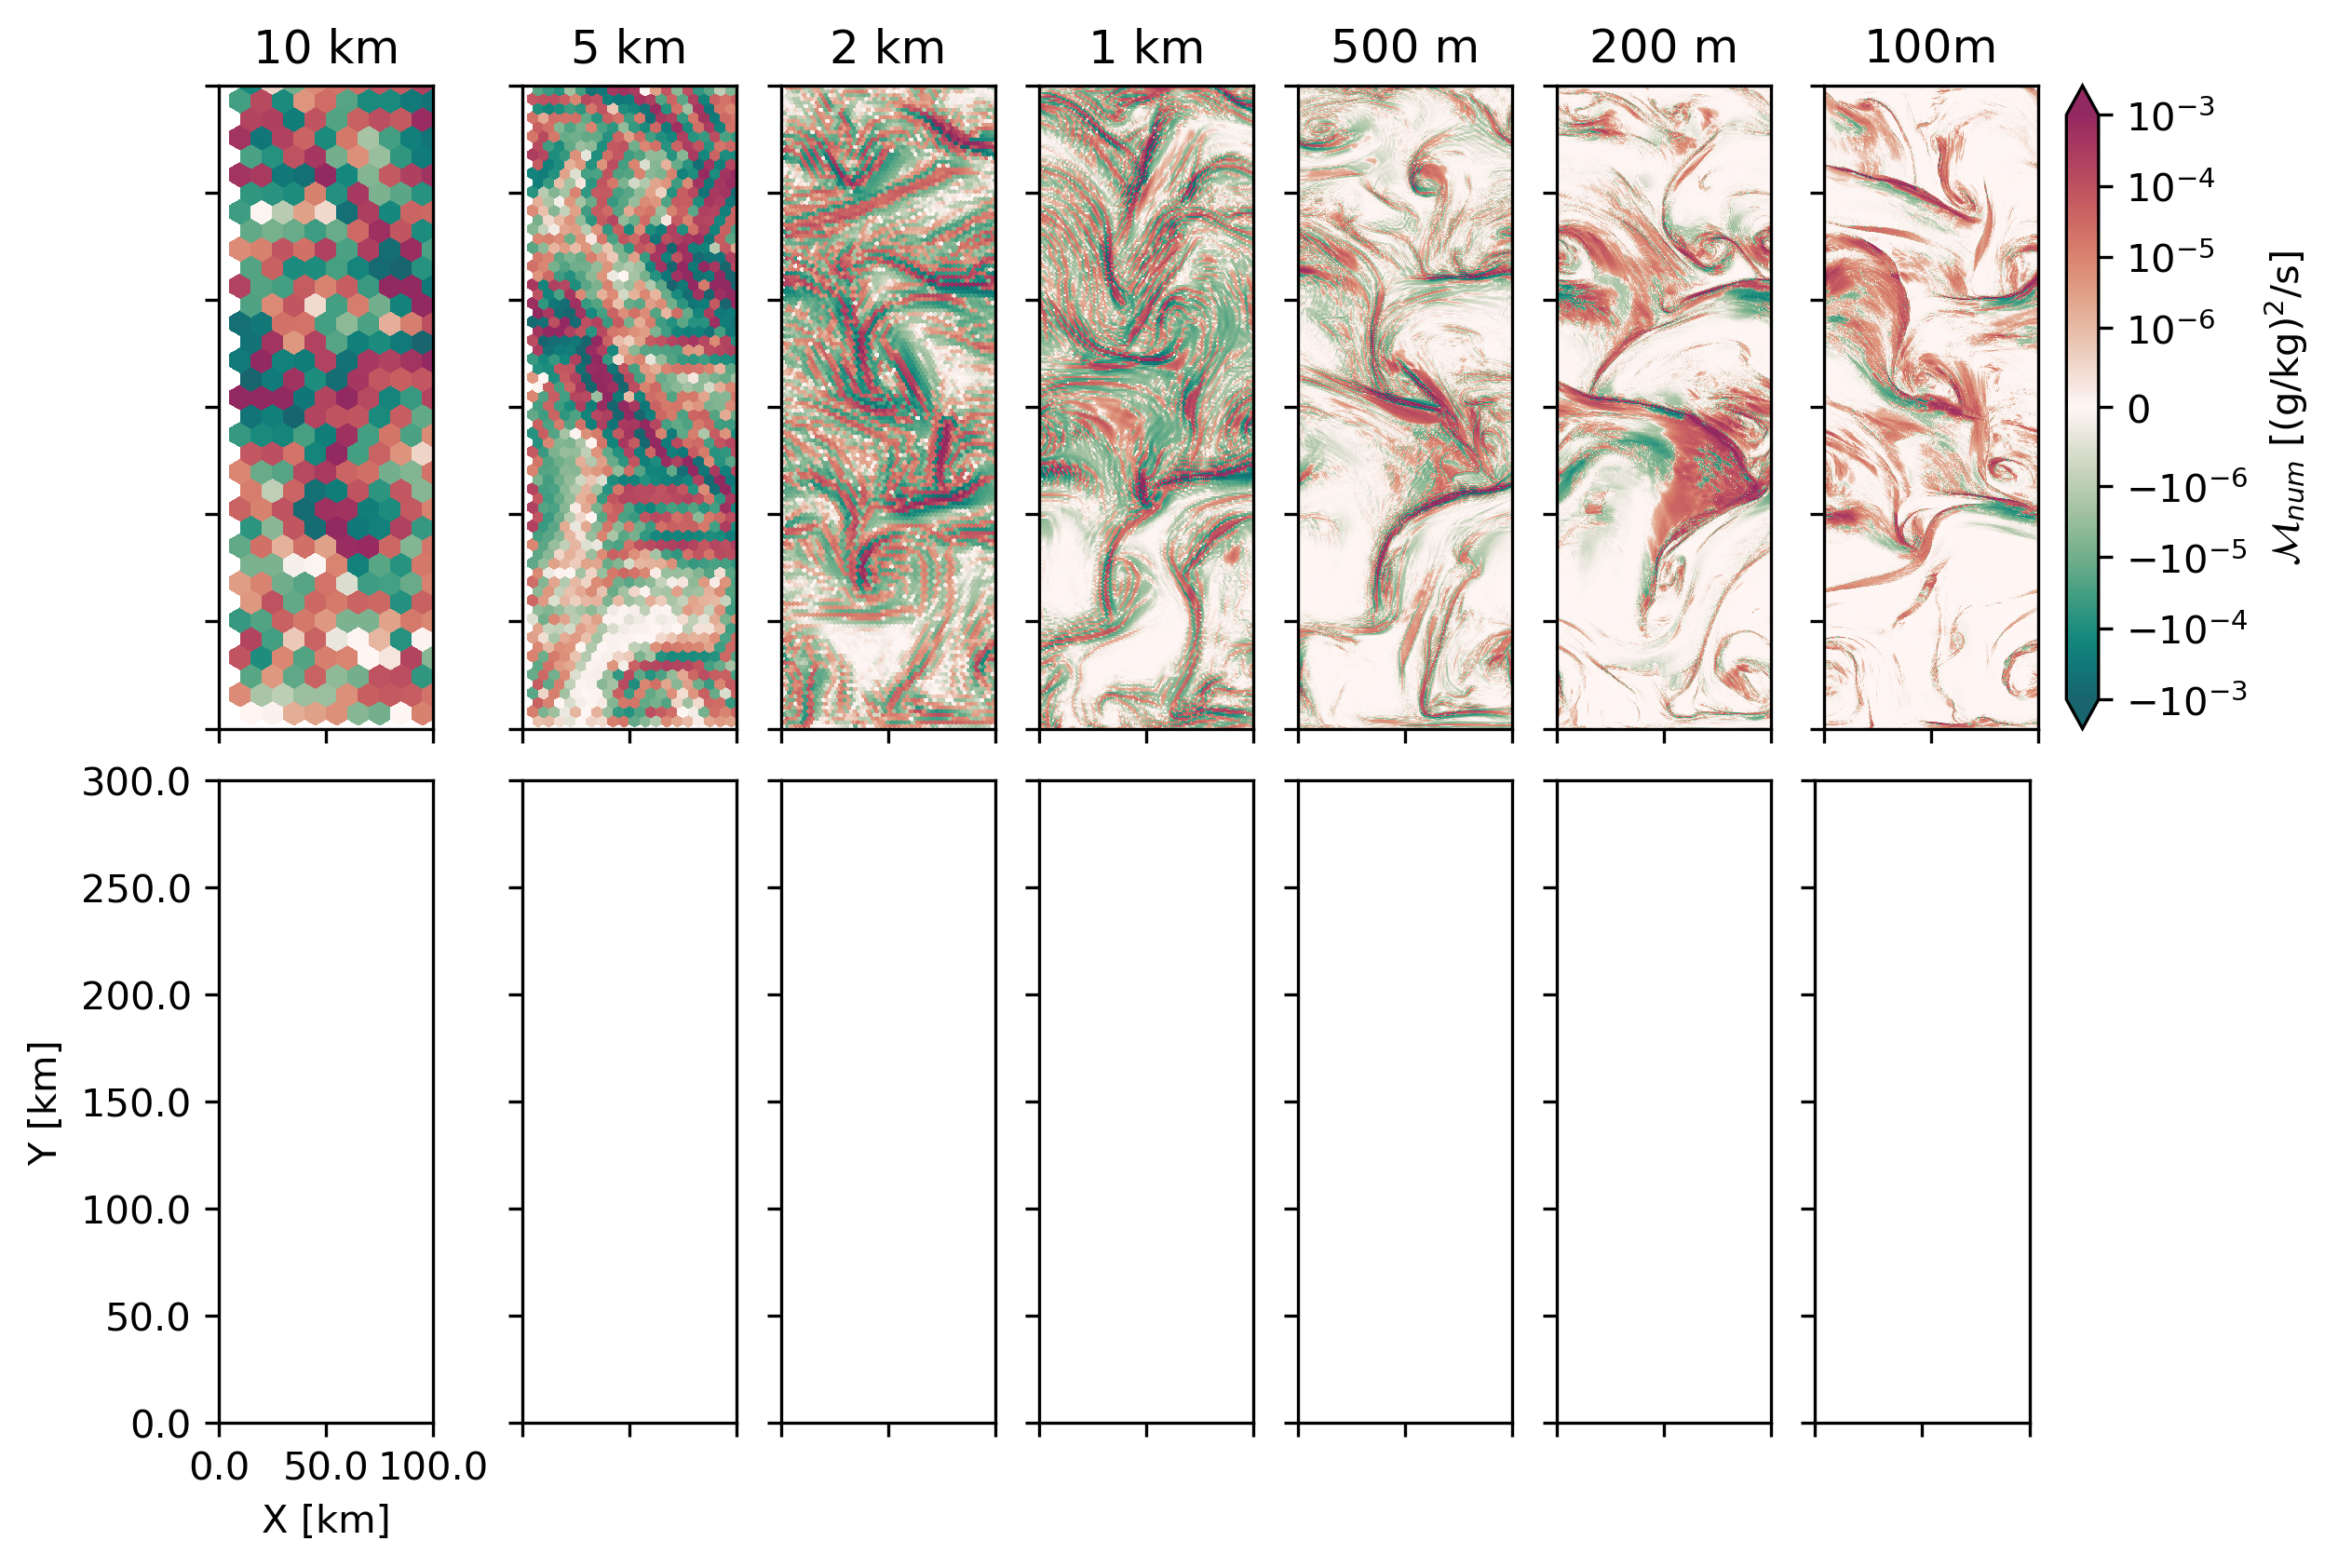

In [11]:
# === Configuration ===
res_keys = ['10000m', '5000m', '2000m', '1000m', '500m', '200m','100m']
titles = ['10 km', '5 km', '2 km', '1 km', '500 m', '200 m', '100m']
z = 0
absmax = 1e-3
linthresh = 1e-6

nrows = 2; ncols = 7
# === Figure and Axes ===
fig, ax = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(8.25, 5.5),
    constrained_layout=True, dpi = 300
)

# === Top row: mnum_salt ===
for j, res_key in enumerate(res_keys):
    a = ax[0, j]

    files = datasets[res_key]['z50']   # ✅ THIS IS THE FIX
    decay = files['output']
    descriptor = descriptors[res_key]

    data = decay.timeCustom_avg_chiSpurTracerBR08_chiSpurSaltBR08.isel(nVertLevels=z)
    norm = SymLogNorm(linthresh=linthresh, vmin=-absmax, vmax=absmax)

    c = mosaic.polypcolor(
        a, descriptor, data,
        cmap=curl,
        norm=norm,
        antialiaseds=False
    )

    a.set_title(titles[j])

# === Colorbar (top row only) ===
cbar_label = r'$\mathcal{M}_{num}$ [(g/kg)$^2$/s]'
fig.colorbar(
    c,
    ax=ax[0, -1],
    label=cbar_label,
    extend='both',
    pad=0.12
)

# === Axis formatting (both rows) ===
for i in range(nrows):
    for j in range(ncols):
        a = ax[i, j]
        a.set_xticks(np.arange(0, 350000, 50000))
        a.set_yticks(np.arange(0, 350000, 50000))
        a.set_xlim(0, 100000)
        a.set_ylim(0, 300000)
        a.set_aspect(1.0)
        a.set_xticklabels([str(x / 1000.0) for x in a.get_xticks()])
        a.set_yticklabels([str(y / 1000.0) for y in a.get_yticks()])
        a.set_xlabel('')
        a.set_ylabel('')

# === Hide all ticks except bottom-left ===
for i in range(nrows):
    for j in range(ncols):
        if not (i == 1 and j == 0):
            ax[i, j].set_xticklabels([])
            ax[i, j].set_yticklabels([])

# === Final axis labels ===
ax[1, 0].set_xlabel('X [km]')
ax[1, 0].set_ylabel('Y [km]')

for j in range(1, 7):
    ax[1, j].set_yticklabels([])

# === Save ===
fig.canvas.draw()
# plt.savefig('plan_view_hres.png', dpi=500)
# plt.show()


Note: Process offline in powerpoint or keynote to remove awkward spacing in the last column 

### Open ROMS

In [12]:
roms_paths = ['/pscratch/sd/k/kehinson/seahorce/roms_channel/bichan_v202601/romsDye03_t132_10km.nc',
              '/pscratch/sd/k/kehinson/seahorce/roms_channel/bichan_v202601/romsDye03_t132_5km.nc',
              '/pscratch/sd/k/kehinson/seahorce/roms_channel/bichan_v202601/romsDye03_t132_2km.nc',
              '/pscratch/sd/k/kehinson/seahorce/roms_channel/bichan_v202601/romsDye03_t132_1km.nc',
              '/pscratch/sd/k/kehinson/seahorce/roms_channel/bichan_v202601/romsDye03_t132_500m.nc',
              '/pscratch/sd/k/kehinson/seahorce/roms_channel/bichan_v202601/romsDye03_t132_200m.nc',
              '/pscratch/sd/k/kehinson/seahorce/roms_channel/bichan_v202601/romsDye03_t132_100m.nc'
             ]

dsr = []
for path in roms_paths:
    dsr.append(xr.open_dataset(path))

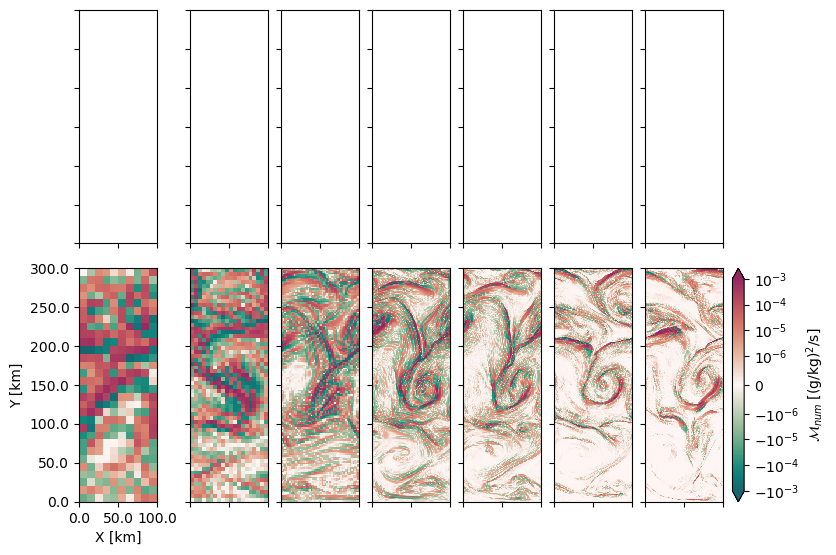

In [18]:
# === Configuration ===
res_keys = ['10000m', '5000m', '2000m', '1000m', '500m', '200m','100m']
titles = ['10 km', '5 km', '2 km', '1 km', '500 m', '200 m', '100m']
z = 0
absmax = 1e-3
linthresh = 1e-6

nrows = 2; ncols = 7
# === Figure and Axes ===
fig, ax = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(8.25, 5.5),
    constrained_layout=True
)

for i in range(7):
    ax[1,i].pcolormesh(dsr[i].x_rho,dsr[i].y_rho,dsr[i].dye_03,         
                       cmap=curl,
                       norm=norm,)
    
# === Colorbar (top row only) ===
cbar_label = r'$\mathcal{M}_{num}$ [(g/kg)$^2$/s]'
fig.colorbar(
    c,
    ax=ax[1, -1],
    label=cbar_label,
    extend='both',
    pad=0.12
)

# === Axis formatting (both rows) ===
for i in range(nrows):
    for j in range(ncols):
        a = ax[i, j]
        a.set_xticks(np.arange(0, 350000, 50000))
        a.set_yticks(np.arange(0, 350000, 50000))
        a.set_xlim(0, 100000)
        a.set_ylim(0, 300000)
        a.set_aspect(1.0)
        a.set_xticklabels([str(x / 1000.0) for x in a.get_xticks()])
        a.set_yticklabels([str(y / 1000.0) for y in a.get_yticks()])
        a.set_xlabel('')
        a.set_ylabel('')

# === Hide all ticks except bottom-left ===
for i in range(nrows):
    for j in range(ncols):
        if not (i == 1 and j == 0):
            ax[i, j].set_xticklabels([])
            ax[i, j].set_yticklabels([])

# === Final axis labels ===
ax[1, 0].set_xlabel('X [km]')
ax[1, 0].set_ylabel('Y [km]')

for j in range(1, 7):
    ax[1, j].set_yticklabels([])

# === Save ===
fig.canvas.draw()
# plt.savefig('plan_view_hres.png', dpi=500)
# plt.show()


### Combine 

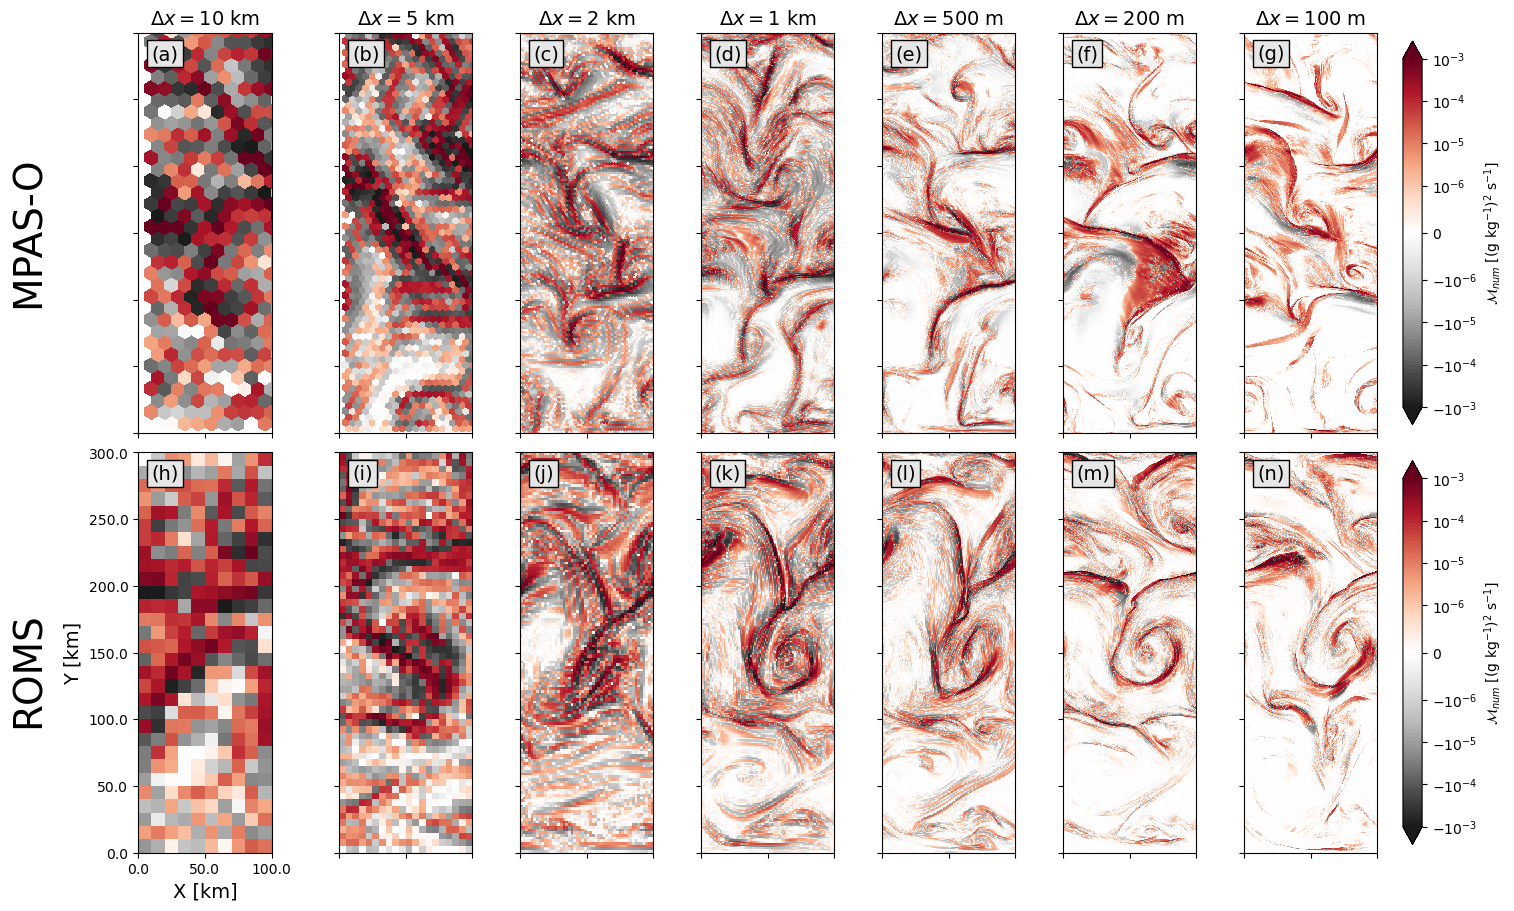

In [20]:
# === Configuration ===
res_keys = ['10000m', '5000m', '2000m', '1000m', '500m', '200m', '100m']
titles = [r'$\Delta x = $10 km', r'$\Delta x = $5 km', r'$\Delta x = $2 km', r'$\Delta x = $1 km', 
          r'$\Delta x = $500 m', r'$\Delta x = $200 m', r'$\Delta x = $100 m']
plabel = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)',
          '(h)', '(i)', '(j)', '(k)', '(l)', '(m)', '(n)']

z = 0
absmax = 1e-3
linthresh = 1e-6
norm = SymLogNorm(linthresh=linthresh, vmin=-absmax, vmax=absmax)

nrows, ncols = 2, 7

# === Figure and Axes ===
fig, ax = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(15, 9),
    constrained_layout=True
)

# ------------------------------------------------
# MPAS-O (top row)
# ------------------------------------------------
for j, res_key in enumerate(res_keys):
    a = ax[0, j]

    files = datasets[res_key]['z50']
    decay = files['output']
    descriptor = descriptors[res_key]

    data = decay.timeCustom_avg_chiSpurTracerBR08_chiSpurSaltBR08.isel(
        nVertLevels=z
    )

    c = mosaic.polypcolor(
        a, descriptor, data,
        cmap=plt.get_cmap('RdGy_r'),
        norm=norm,
        antialiaseds=False
    )

    a.set_autoscale_on(False)
    a.set_xlim(0, 100000)
    a.set_ylim(0, 300000)
    a.set_aspect(1.0)

    a.set_title(titles[j], fontsize=14)
    a.text(
        10000.0, 280000.0, plabel[j],
        bbox=dict(facecolor='0.9', edgecolor='k', pad=3.0),
        size=14
    )

    # Remove all tick labels on top row
    a.set_xticklabels([])
    a.set_yticklabels([])

# === Colorbar (MPAS-O row) ===
cbar_label = r'$\mathcal{M}_{num}$ [(g kg$^{-1}$)$^2$ s$^{-1}$]'
fig.colorbar(
    c,
    ax=ax[0, :],
    location='right',
    fraction=0.015,
    pad=0.02,
    label=cbar_label,
    extend='both'
)

# ------------------------------------------------
# ROMS (bottom row)
# ------------------------------------------------
for i in range(ncols):
    a = ax[1, i]

    a.pcolormesh(
        dsr[i].x_rho,
        dsr[i].y_rho,
        dsr[i].dye_03,
        cmap=plt.get_cmap('RdGy_r'),
        norm=norm
    )

    a.set_xlim(0, 100000)
    a.set_ylim(0, 300000)
    a.set_aspect(1.0)

    a.text(
        10000.0, 280000.0, plabel[i + 7],
        bbox=dict(facecolor='0.9', edgecolor='k', pad=3.0),
        size=14
    )
    
    # Remove x/y tick labels for all except bottom-left [1,0]
    if i != 0:
        a.set_yticklabels([])
    if i != 0:
        a.set_xticklabels([])

# === Colorbar (ROMS row) ===
fig.colorbar(
    c,
    ax=ax[1, :],
    location='right',
    fraction=0.015,
    pad=0.02,
    label=cbar_label,
    extend='both'
)

# ------------------------------------------------
# Tick locations + formatting
# ------------------------------------------------
for i in range(nrows):
    for j in range(ncols):
        a = ax[i, j]
        a.set_xticks(np.arange(0, 110000, 50000))
        a.set_yticks(np.arange(0, 500000, 50000))
        a.set_aspect(1.0)
        a.set_xlim(0, 100000)
        a.set_ylim(0, 300000)
        a.set_xlabel('')
        a.set_ylabel('')

# ------------------------------------------------
# Show tick labels only for bottom-left subplot [1,0]
# ------------------------------------------------
ax[1, 0].set_xticklabels([str(x/1000.0) for x in ax[1, 0].get_xticks()])
ax[1, 0].set_yticklabels([str(y/1000.0) for y in ax[1, 0].get_yticks()])
ax[1, 0].set_xlabel('X [km]', fontsize=14)
ax[1, 0].set_ylabel('Y [km]', fontsize=14)

# Row labels
ax[0, 0].text(-96000.0, 100000.0, 'MPAS-O', size=28, rotation=90)
ax[1, 0].text(-96000.0, 100000.0, 'ROMS', size=28, rotation=90)

# ------------------------------------------------
# Save / show
# ------------------------------------------------
fig.canvas.draw()
# plt.show()
plt.savefig('plan_view_mnum.png', dpi=500)
